# **Multimodal Sensor Fusion: Frame Camera and Event Camera**

In this laboratory we will combine data from two fundamentally different imaging sensors  a conventional **frame camera** (Basler) and a **Dynamic Vision Sensor** (DVS/EVK4 event camera)  into a unified coordinate space.

The goal of multimodal fusion is to leverage the strengths of both sensors simultaneously:
- The frame camera provides **high-resolution, color-rich images** captured at a fixed rate.
- The event camera provides **ultra-fast, low-latency measurements** of brightness changes with microsecond temporal resolution.

By calibrating and aligning these two modalities, we can project detections (such as faces) from one sensor's image plane directly onto the other.

---

## What You Will Learn

1. **Load and interpret camera intrinsic parameters** from calibration files.
2. **Estimate extrinsic parameters** (rotation $R$ and translation $t$) between the frame camera and the event camera using a chessboard calibration target.
3. **Triangulate 3D points** from stereo correspondences to estimate scene depth.
4. **Validate calibration quality** by measuring cross-sensor reprojection errors.
5. **Detect faces** in frame images using the InsightFace framework.
6. **Project face detections** from the frame camera coordinate system to the event camera coordinate system and visualize the result.

---

## Frame Camera vs. Event Camera

| Feature | Frame Camera | Event Camera (DVS) |
|---|---|---|
| Output | Full intensity frames at fixed rate | Asynchronous per-pixel brightness change events |
| Temporal resolution | ~30 120 fps | ~1 Âµs effective resolution |
| Latency | High (frame period) | Very low (µs) |
| Dynamic range | ~60 dB | >120 dB |
| Data redundancy | High (all pixels every frame) | Low (only changed pixels) |
| Suitable for | Rich texture, color, face images | Fast motion, HDR scenes, tracking |

---

## Dataset

We use a synchronized dataset recorded with a **Basler a2A frame camera** and an **EVK4 event camera** rigidly mounted together.

The dataset contains:
- Chessboard images for calibration (frame camera images + DVS corner detections)
- Driving scene recordings (face images + DVS event streams with trigger synchronization)

# Camera Model Background

Before working with two cameras jointly, we need to understand how each camera maps the 3D world to a 2D image.

---

## Intrinsic Parameters

A **pinhole camera** projects a 3D point $\mathbf{P} = [X, Y, Z]^T$ onto the image plane at pixel $\mathbf{p} = [u, v]^T$ via the **intrinsic matrix** $K$:

$$\mathbf{p} = K \begin{bmatrix} X/Z \\ Y/Z \\ 1 \end{bmatrix}, \quad K = \begin{bmatrix} f_x & 0 & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}$$

where:
- $f_x$, $f_y$  focal lengths (in pixels)
- $c_x$, $c_y$  principal point (optical axis projection onto the image, in pixels)

Real lenses also introduce **distortion**, captured by the distortion coefficient vector $D = [k_1, k_2, p_1, p_2, k_3]$, where $k_i$ are radial distortion coefficients and $p_i$ are tangential coefficients.

---

## Extrinsic Parameters

When two cameras are rigidly mounted together, their relationship is described by **extrinsic parameters**: a rotation matrix $R$ (3Ã—3) and a translation vector $t$ (3Ã—1). Together they transform a 3D point from camera 1's coordinate system into camera 2's coordinate system:

$$\mathbf{P}_{cam2} = R \cdot \mathbf{P}_{cam1} + \mathbf{t}$$

Estimating these parameters from corresponding observations in both cameras is called **stereo calibration** or **extrinsic calibration**.

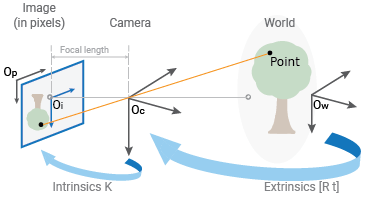

# Environment Setup

Import the required libraries.

- **NumPy** — for numerical operations and array manipulation,
- **OpenCV (`cv2`)** — for camera calibration, undistortion, and projection,
- **json** — for reading calibration files,
- **h5py** — for reading DVS event data in HDF5 format,
- **matplotlib** — for inline visualization,
- **insightface** — for face detection and landmark estimation,
- **tqdm** — for progress bars during batch processing,
- **glob, re, pathlib** — for file system operations.

You may need to install the required packages in your **virtual environment**:

```bash
source ./myenv/bin/activate
TMPDIR=~/tmp pip install opencv-python numpy h5py matplotlib insightface tqdm
```

In [ ]:
import subprocess, sys

packages = [
    "opencv-python",
    "numpy",
    "h5py",
    "matplotlib",
    "insightface",
    "onnxruntime",
    "nvidia-cudnn-cu12",
    "tqdm",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])
print("All packages installed.")


In [ ]:
import os
import json
import glob
import re
import numpy as np
import cv2
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from insightface.app import FaceAnalysis

# Loading Camera Intrinsics

## Intrinsics File Format

Each camera's intrinsic parameters are stored in a JSON file with the following structure:

```json
{
  "type": "pinhole",
  "width": 1280,
  "height": 720,
  "K": [ fx, 0, cx, 0, fy, cy, 0, 0, 1 ],
  "D": [ k1, k2, p1, p2, k3 ]
}
```

The `K` array is a row-major flattened 3×3 matrix. We reshape it to a proper 3×3 NumPy array. The `D` array holds up to 5 distortion coefficients (OpenCV format).

We have two calibration files:
- `intrinsicsBasler.json` — **Frame camera** (Basler a2A, 1280×720)
- `intrinsicsEVK4.json` — **Event camera** (Prophesee EVK4, 1280×720)

In [ ]:
# ── File paths ──────────────────────────────────────────────────────────────────

# Intrinsics files (provided with the lab)
FRAME_INTRINSICS_FILE = "intrinsicsBasler.json"
DVS_INTRINSICS_FILE   = "intrinsicsEVK4.json"

# Chessboard detections JSON for extrinsic calibration
DETECTIONS_FILE = "detections.json"

# DVS calibration events HDF5 file
EVENTS_FILE = "../datasetFaces/events.hdf5"

# Frame calibration images directory
FRAMES_DIR = "../datasetFaces/frames_1280"

# Face detections output directory (InsightFace .npy files)
FACES_DIR = "../npyData"

# Output file for estimated extrinsic parameters
EXTRINSICS_OUTPUT = "extrinsics.json"

# ── Calibration constants ────────────────────────────────────────────────────────

# Chessboard pattern size: number of inner corners (cols, rows)
PATTERN_SIZE = (9, 6)

print("Paths configured.")
print(f"  Frame intrinsics : {FRAME_INTRINSICS_FILE}")
print(f"  DVS intrinsics   : {DVS_INTRINSICS_FILE}")
print(f"  Detections file  : {DETECTIONS_FILE}")
print(f"  Events file      : {EVENTS_FILE}")
print(f"  Frames directory : {FRAMES_DIR}")
print(f"  Faces directory  : {FACES_DIR}")
print(f"  Chessboard size  : {PATTERN_SIZE[0]} Ã— {PATTERN_SIZE[1]} inner corners")

In [ ]:
# Load frame camera (Basler) intrinsics
with open(FRAME_INTRINSICS_FILE, 'r') as f:
    frame_data = json.load(f)

frame_K          = np.array(frame_data['K']).reshape(3, 3)
frame_D          = np.array(frame_data['D'])
frame_image_size = (frame_data['width'], frame_data['height'])

print("Frame Camera (Basler) Intrinsics")
print(f"  Image size: {frame_image_size[0]} Ã— {frame_image_size[1]}")
print(f"  K:\n{frame_K}")
print(f"  D: {frame_D}\n")

# Load DVS (EVK4) intrinsics
with open(DVS_INTRINSICS_FILE, 'r') as f:
    dvs_data = json.load(f)

dvs_K          = np.array(dvs_data['K']).reshape(3, 3)
dvs_D          = np.array(dvs_data['D'])
dvs_image_size = (dvs_data['width'], dvs_data['height'])

print("Event Camera (EVK4) Intrinsics")
print(f"  Image size: {dvs_image_size[0]} Ã— {dvs_image_size[1]}")
print(f"  K:\n{dvs_K}")
print(f"  D: {dvs_D}")

## Inspecting the Intrinsics

Look at the $K$ matrices and distortion vectors printed above.

**TODO:** Answer the following questions before continuing:

1. What are the focal lengths $f_x$ and $f_y$ for the frame camera and the event camera? Are they similar? What does a larger focal length imply about the field of view?

-> The focal lens is the distance of the lens to the sensor of the camera. the focal the lense lenght of this two camera are not the same. The EVK4 has fx=851.36 and fy=851.36 and for Basler camera : fx = 1025 fy = 1029 so not the same for both camera.
The larger is the focal lens the less the FOV are.

2. Where are the principal points $c_x$, $c_y$ located relative to the image center (640, 360)? What could explain a non-centered principal point?

-> Basler: cx=639.5, cy=359.5 and real center is 640/360 so it's nearly centered
-> EVK4: cx=633.71, cy=375.70 and real center is the same as the prevous one.. so it's not well centerd, especialy in y.

This misaligment is maybe because the lens is not mounting well perpendicular on the lens or sensor misplacement.

3. Compare the distortion coefficients $D$ for both cameras. Which camera has stronger radial distortion? (Hint: look at $k_1$, the coefficient with the largest magnitude.)

-> Both cameras have a similar dominant (0.229 and 0.227) However the Basler has stronger higher-order distortion k_2 (0.121 vs 0.070) that means the basler camera has stronger radial distortion.

4. Why do we need to correct for lens distortion before performing stereo calibration or point projection?

->  The pinhole camera model (and cv2.stereoCalibrate) assumes that pixel coordinates are linearly related to 3D directions. Lens distortion breaks this assumptio

# Stereo Extrinsic Calibration

## Theory

To determine the **relative pose** (rotation and translation) between the frame camera and the event camera, we present a **chessboard calibration target** in front of both sensors simultaneously and detect the inner corner positions in both images.

### 3D Chessboard Points

We define a set of known 3D points on the chessboard in a local coordinate frame where the board lies in the $Z=0$ plane:

$$\mathbf{X}_{ij} = [j \cdot s, \; i \cdot s, \; 0]^T, \quad i = 0 \ldots \text{rows}-1, \quad j = 0 \ldots \text{cols}-1$$

where $s$ is the square size (we use unit size since only the relative pose matters here).

### Stereo Calibration

Given corresponding 2D detections in both cameras for $N$ frames, we use `cv2.stereoCalibrate()` with the `CALIB_FIX_INTRINSIC` flag, which keeps both $K$ matrices and distortion vectors fixed at the values we already loaded. The calibration minimizes the **total reprojection error**:

$$E = \frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{M} \left\| \mathbf{p}^{(1)}_{ij} - \hat{\mathbf{p}}^{(1)}_{ij}(R, t) \right\|^2 + \left\| \mathbf{p}^{(2)}_{ij} - \hat{\mathbf{p}}^{(2)}_{ij}(R, t) \right\|^2$$

where $\mathbf{p}$ are the detected corners and $\hat{\mathbf{p}}$ are the corners reprojected from the estimated 3D position.

The output is the rotation matrix $R$ and translation vector $t$ that transform 3D points from the **frame camera** coordinate system to the **event camera** coordinate system.

In [ ]:
# Load chessboard detections from JSON
with open(DETECTIONS_FILE, 'r') as f:
    detections_data = json.load(f)

PATTERN_SIZE  = tuple(detections_data['pattern_size'])   # override from file
detections    = detections_data['detections']

print(f"Pattern size : {PATTERN_SIZE[0]} Ã— {PATTERN_SIZE[1]} inner corners")
print(f"Total detections loaded: {len(detections)}")

# Ensure consistent left-to-right corner ordering in each detection
cols, rows = PATTERN_SIZE

def get_ordering(corners, cols):
    """Return 'ltr' if first row goes left-to-right, 'rtl' otherwise."""
    return 'ltr' if corners[0][0] < corners[cols - 1][0] else 'rtl'

frame_orderings = [get_ordering(d['frame_corners'], cols) for d in detections]
event_orderings = [get_ordering(d['event_corners'], cols) for d in detections]

unique_frame = set(frame_orderings)
unique_event = set(event_orderings)

if len(unique_frame) > 1:
    print(f"WARNING: Mixed frame corner orderings detected across detections: {unique_frame}")
else:
    print(f"Frame corners ordering : {next(iter(unique_frame))} (consistent across all detections)")

if len(unique_event) > 1:
    print(f"WARNING: Mixed event corner orderings detected across detections: {unique_event}")
else:
    print(f"Event corners ordering : {next(iter(unique_event))} (consistent across all detections)")

# Normalize all detections to left-to-right ordering
for det in detections:
    fc = np.array(det['frame_corners'])
    ec = np.array(det['event_corners'])
    if get_ordering(fc, cols) == 'rtl':
        det['frame_corners'] = fc[::-1].tolist()
    if get_ordering(ec, cols) == 'rtl':
        det['event_corners'] = ec[::-1].tolist()

print("Corner ordering normalized to left-to-right for all detections.")


In [ ]:
# Prepare calibration data: 3D object points and 2D image point pairs

cols, rows = PATTERN_SIZE
square_size = 1.0  # Unit square size  only relative pose matters

# 3D chessboard corners in the chessboard coordinate frame (Z = 0)
objp = np.zeros((rows * cols, 3), np.float32)
objp[:, :2] = np.mgrid[0:cols, 0:rows].T.reshape(-1, 2) * square_size

object_points  = []   # 3D world points (same for every frame)
frame_points   = []   # 2D corners detected in the frame camera
dvs_points     = []   # 2D corners detected in the event camera
frame_indices  = []   # Frame index of each detection (for visualization)   

expected_corners = rows * cols

# TODO: Convert the detections to a lists (empty declared above).
# Frame corners and event corners should be converted to numpy arrays of shape (N, 2) where N is the number of detected corners of of float32 type and added to `frame_points` and `dvs_points` respectively.
# The 3D object points (objp) should be added to `object_points` for each valid detection pair. All of these points are the same for every detection since they represent the known geometry of the chessboard.
# The frame index should be extracted from the detection and added to `frame_indices` for each valid detection pair. This will be useful for visualization later on.
for det in detections:
    fc = np.array(det['frame_corners'], dtype=np.float32)  # (N, 2)
    ec = np.array(det['event_corners'],  dtype=np.float32)  # (N, 2)

    if len(fc) != expected_corners or len(ec) != expected_corners:
        continue  # skip incomplete detections

    frame_points.append(fc)
    dvs_points.append(ec)
    object_points.append(objp)
    frame_indices.append(det['frame_index'])

print(f"Expected corners per frame : {expected_corners}")
print(f"Valid detection pairs      : {len(object_points)}")

if len(object_points) < 5:
    print("WARNING: Fewer than 5 valid pairs  calibration may be unreliable.")


In [ ]:
# Perform stereo calibration to estimate R and t

# Fix intrinsic parameters  we trust the pre-calibrated K and D matrices
flags    = cv2.CALIB_FIX_INTRINSIC
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 1e-5)

# Subsample to 50 evenly-spaced pairs , 362 pairs is too much than needed
# and makes stereoCalibrate very slow; 20 70 diverse views is sufficient
MAX_PAIRS = 70
step = max(1, len(object_points) // MAX_PAIRS)
idx_sub = list(range(0, len(object_points), step))[:MAX_PAIRS]

# Reshape to OpenCV's expected format: (N, 1, 3) for 3D and (N, 1, 2) for 2D points
object_points_cv = [object_points[i].reshape(-1, 1, 3) for i in idx_sub]
frame_points_cv  = [frame_points[i].reshape(-1, 1, 2)  for i in idx_sub]
dvs_points_cv    = [dvs_points[i].reshape(-1, 1, 2)    for i in idx_sub]

print(f"Using {len(idx_sub)} / {len(object_points)} detection pairs for calibration.")

ret, K1, D1, K2, D2, R, t, E, F = cv2.stereoCalibrate(
    object_points_cv,
    frame_points_cv,   # Camera 1: frame camera (Basler)
    dvs_points_cv,     # Camera 2: event camera (EVK4)
    frame_K, frame_D,
    dvs_K, dvs_D,
    frame_image_size,
    criteria=criteria,
    flags=flags
)

reprojection_error = ret

print(f"Stereo calibration completed.")
print(f"Reprojection error : {reprojection_error:.4f} pixels")
print(f"\nRotation matrix R:\n{R}")
print(f"\nTranslation vector t: {t.flatten()}")


## Interpreting the Calibration Results

### Reprojection Error

A reprojection error below **1 pixel** indicates excellent calibration. Between 1 3 pixels is acceptable for practical use. Above 5 pixels suggests problems such as inaccurate corner detections, insufficient data diversity, or poor chessboard coverage.

### Rotation Matrix

The raw 3Ã—3 rotation matrix $R$ is not easy to interpret directly. More intuitive representations are:

- **Axis-angle**: The rotation can be expressed as a single rotation of angle $\theta$ around a unit axis $\hat{n}$.
  Using OpenCV's `cv2.Rodrigues()`: $\text{rvec} = \hat{n} \cdot \theta$ and $\theta = \|\text{rvec}\|$.

- **Euler angles** (ZYX / roll-pitch-yaw convention):
  $$sy = cos(\beta) = \sqrt{R_{00}^2 + R_{10}^2}$$
  $$\alpha = \arctan2(R_{21}, R_{22}), \quad \beta = \arctan2(-R_{20}, \sqrt{R_{00}^2 + R_{10}^2}), \quad \gamma = \arctan2(R_{10}, R_{00})$$

### Translation Vector

The translation vector $\mathbf{t}$ gives the displacement of the frame camera's origin in the event camera's coordinate system. Its magnitude is the physical distance between the two camera optical centers (in the same units as the square size used in calibration).

In [ ]:
# Convert rotation matrix to more interpretable forms

#  Axis-angle representation via Rodrigues decomposition
# TODO: Convert the rotation matrix R to axis-angle representation using Rodrigues decomposition.
# The resulting rotation vector (rvec) should be flattened to a 1D array. The angle of rotation in radians can be computed as the norm of the rotation vector, and then converted to degrees.
# The rotation axis can be obtained by normalizing the rotation vector (dividing by its norm), but only if the angle is greater than a small threshold to avoid division by zero.
# If the angle is very small, you can default the axis to a standard unit vector (e.g., [0, 0, 1]) since the rotation is negligible.
rvec, _ = cv2.Rodrigues(R)
rvec = rvec.flatten()
angle_rad = np.linalg.norm(rvec)
angle_deg = np.degrees(angle_rad)
axis = rvec / angle_rad if angle_rad > 1e-6 else np.array([0.0, 0.0, 1.0])

#  Euler angles (ZYX convention: roll = X, pitch = Y, yaw = Z)
# TODO: Convert the rotation matrix R to Euler angles using the ZYX convention. This involves computing the angles based on the elements of the rotation matrix.
# The formulas for roll, pitch, and yaw can be derived from the structure of the rotation matrix, but care must be taken to handle cases where certain elements are close to zero to avoid numerical instability.
# Start by calculating the sy (cosine of pitch) term to check for gimbal lock, check if the value is greater than 1e-6 then compute roll, pitch, and yaw according to the equations given in the description above.
# Why do we need to check the cosine of the pitch angle (sy)? What happens if this value is close to 0? Check this using the 'gimbal_lock.py' script and answer.
# If there is a gimbal lock (sy close to 0), calculate roll as arctan2(-R[1, 2], R[1, 1]), pitch as arctan2(-R[2, 0], sy), and yaw as 0.
# Then convert the angles to degrees for easier interpretation.
sy = np.sqrt(R[0, 0]**2 + R[1, 0]**2)
if sy > 1e-6:
    roll  = np.arctan2(R[2, 1], R[2, 2])
    pitch = np.arctan2(-R[2, 0], sy)
    yaw   = np.arctan2(R[1, 0], R[0, 0])
else:  # gimbal lock
    roll  = np.arctan2(-R[1, 2], R[1, 1])
    pitch = np.arctan2(-R[2, 0], sy)
    yaw   = 0.0
euler_deg = np.degrees([roll, pitch, yaw])

#  Translation magnitude and direction
# TODO: Compute the magnitude of the translation vector t and its direction.
# The magnitude can be calculated as the Euclidean norm of the translation vector, and the direction can be obtained by normalizing the translation vector (dividing by its magnitude).
# Again, if the magnitude is very small, you can default the direction to a zero vector.
t_flat = t.flatten()
t_magnitude = np.linalg.norm(t_flat)
t_direction = t_flat / t_magnitude if t_magnitude > 1e-6 else np.zeros(3)

print("Rotation Analysis")
print(f"  Axis         : {axis}")
print(f"  Angle        : {angle_deg:.4f}Â°")
print(f"  Euler (X,Y,Z): roll={euler_deg[0]:.4f}Â°  pitch={euler_deg[1]:.4f}Â°  yaw={euler_deg[2]:.4f}Â°")

print("\nTranslation Analysis")
print(f"  Vector    : {t_flat}")
print(f"  Magnitude : {t_magnitude:.6f}")
print(f"  Direction : {t_direction}")


# Triangulation and Depth Estimation

## Theory

**Triangulation** recovers the 3D position of a point given its projections in two calibrated cameras. Because each 2D observation defines a ray in 3D space, the 3D point lies at the intersection of the two rays from both cameras.

Given:
- Projection matrix of the frame camera: $P_1 = K_1 \begin{bmatrix} I \mid \mathbf{0} \end{bmatrix}$
- Projection matrix of the event camera: $P_2 = K_2 \begin{bmatrix} R \mid \mathbf{t} \end{bmatrix}$
- Corresponding undistorted 2D points $\mathbf{p}_1$ and $\mathbf{p}_2$

OpenCV's `cv2.triangulatePoints(P1, P2, pts1, pts2)` returns homogeneous 4D points $\tilde{\mathbf{X}} = [X, Y, Z, W]^T$. We recover 3D Euclidean coordinates by normalizing:

$$\mathbf{X} = \frac{1}{W} \begin{bmatrix} X \\ Y \\ Z \end{bmatrix}$$

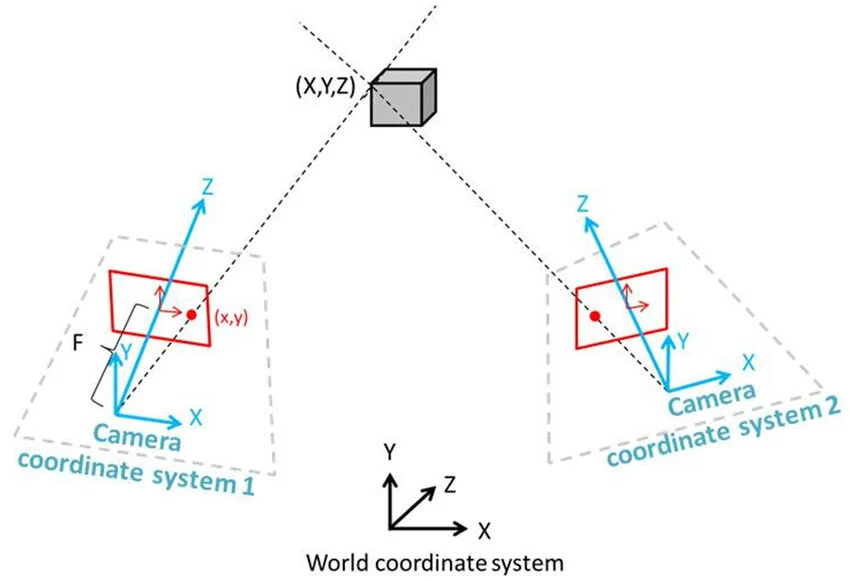


### Depth

The **depth** of a point is its $Z$-coordinate in the frame camera's coordinate system  i.e., its distance along the optical axis. Since the chessboard is placed at a known distance from the cameras, the mean depth of all triangulated chessboard corners gives us a **calibrated depth estimate** that we will later use to project face detections.

In [ ]:
# Build camera projection matrices
# Frame camera is at the world origin: P1 = K1 * [I | 0]
# TODO: Calculate the projection matrix P1 for the frame camera.
P1 = frame_K @ np.hstack([np.eye(3), np.zeros((3, 1))])

# Event camera is transformed by R and t: P2 = K2 * [R | t]
# TODO: Calculate the projection matrix P2 for the event camera using the estimated rotation R and translation t.
P2 = dvs_K @ np.hstack([R, t])

print("Projection matrix P1 (frame camera):\n", P1)
print("\nProjection matrix P2 (event camera):\n", P2)

# Triangulate all corresponding chessboard corners
all_points_3d = []
all_depths    = []

for frame_pts, dvs_pts in zip(frame_points, dvs_points):
    # Undistort before triangulation (remove lens distortion)
    frame_pts_undist = cv2.undistortPoints(
        frame_pts.reshape(-1, 1, 2), frame_K, frame_D, P=frame_K
    ).reshape(-1, 2)
    dvs_pts_undist = cv2.undistortPoints(
        dvs_pts.reshape(-1, 1, 2), dvs_K, dvs_D, P=dvs_K
    ).reshape(-1, 2)

    # Triangulate: returns 4Ã—N homogeneous points
    pts_4d = cv2.triangulatePoints(P1, P2, frame_pts_undist.T, dvs_pts_undist.T)

    # Convert to 3D Euclidean coordinates
    pts_3d = (pts_4d[:3] / pts_4d[3]).T   # shape: (N, 3)
    all_points_3d.append(pts_3d)
    all_depths.extend(pts_3d[:, 2].tolist())  # Z-coordinate = depth

triangulated_points = np.vstack(all_points_3d)
all_depths = np.array(all_depths)

# Compute depth statistics
depth_stats = {
    'mean'  : float(np.mean(all_depths)),
    'std'   : float(np.std(all_depths)),
    'min'   : float(np.min(all_depths)),
    'max'   : float(np.max(all_depths)),
    'median': float(np.median(all_depths)),
    'count' : int(len(all_depths))
}

print(f"\nTriangulated {len(triangulated_points)} 3D points from {len(frame_points)} detection pairs.")
print(f"\nDepth Statistics (Z-coordinate in frame camera frame):")
print(f"  Mean   : {depth_stats['mean']:.4f}")
print(f"  Std    : {depth_stats['std']:.4f}")
print(f"  Median : {depth_stats['median']:.4f}")
print(f"  Range  : [{depth_stats['min']:.4f},  {depth_stats['max']:.4f}]")

# Store the assumed depth for later use in face projection
assumed_depth = depth_stats['mean']
print(f"\nAssumed depth for face projection: {assumed_depth:.4f}")


## Calibration Validation: Cross-Camera Projection

Before using the extrinsics in the field, we validate them by checking how accurately we can **project points across cameras**.

### The 4-Step Projection Pipeline (Frame Camera â†’ Event Camera)

Given a 2D pixel in the frame camera image and an assumed depth $d$:

1. **Undistort** the pixel to normalized (distortion-free) coordinates:
   $$\tilde{\mathbf{p}} = K_1^{-1} \cdot \text{undistort}(\mathbf{p}_1)$$

2. **Back-project to 3D** using depth $d$:
   $$\mathbf{P}_{frame} = \begin{bmatrix} \tilde{x} \cdot d \\ \tilde{y} \cdot d \\ d \end{bmatrix}$$

3. **Transform** to the event camera coordinate system:
   $$\mathbf{P}_{dvs} = R \cdot \mathbf{P}_{frame} + \mathbf{t}$$

4. **Project** onto the event camera image plane (with distortion):
   $$\mathbf{p}_2 = \text{projectPoints}(\mathbf{P}_{dvs},\; K_2,\; D_2)$$

The same pipeline in reverse (event camera â†’ frame camera) uses $R^T$ and $-R^T \mathbf{t}$.

In [ ]:
def project_frame_to_dvs(frame_pts, depth, frame_K, frame_D, dvs_K, dvs_D, R, t):
    """Project 2D points from the frame camera image to the DVS image.

    Args:
        frame_pts : (N, 2) float32 array of pixel coordinates in the frame camera.
        depth     : Scalar depth (Z distance in metres, or in calibration units).
        frame_K, frame_D : Frame camera intrinsics.
        dvs_K, dvs_D     : DVS intrinsics.
        R  : (3, 3) rotation matrix (frame â†’ DVS).
        t  : (3, 1) translation vector (frame â†’ DVS).

    Returns:
        (N, 2) float32 array of projected pixel coordinates in the DVS image.
    """
    # Step 1  undistort to normalised (distortion-free) coordinates
    norm_pts = cv2.undistortPoints(
        frame_pts.reshape(-1, 1, 2), frame_K, frame_D
    ).reshape(-1, 2)     # shape (N, 2), each row is (x_n, y_n)

    # Step 2  back-project to 3D using the assumed depth
    # TODO: Back-project the undistorted 2D points to 3D coordinates in the frame camera coordinate system using the assumed depth.
    # The X and Y coordinates can be calculated as x_n * depth and y_n * depth respectively, where (x_n, y_n) are the normalized coord
    # inates.
    # The Z coordinate is simply the depth value. This will give you the 3D coordinates of the points in the frame camera coordinate system, which can then be transformed to the DVS coordinate system.
    # Shape of pts_3d_frame should be (N, 3) where each row is (X, Y, Z) in the frame camera coordinate system.
    pts_3d_frame = np.column_stack([
        norm_pts[:, 0] * depth,
        norm_pts[:, 1] * depth,
        np.full(len(norm_pts), depth)
    ])  # shape (N, 3)

    # Step 3  transform to DVS coordinate system: P_dvs = R * P_frame + t
    pts_3d_dvs = (R @ pts_3d_frame.T).T + t.T   # shape (N, 3)

    # Step 4  project to DVS image plane with distortion
    pts_2d_dvs, _ = cv2.projectPoints(
        pts_3d_dvs.reshape(-1, 1, 3),
        np.zeros(3),   # no extra rotation
        np.zeros(3),   # no extra translation
        dvs_K, dvs_D
    )
    return pts_2d_dvs.reshape(-1, 2)


def project_dvs_to_frame(dvs_pts, depth, frame_K, frame_D, dvs_K, dvs_D, R, t):
    """Project 2D points from the DVS image back to the frame camera image."""
    # Undistort DVS points
    norm_pts = cv2.undistortPoints(
        dvs_pts.reshape(-1, 1, 2), dvs_K, dvs_D
    ).reshape(-1, 2)

    # TODO: Back-project the undistorted DVS points to 3D coordinates in the DVS camera coordinate system using the assumed depth.
    # This is done similarly to the frame camera back-projection, but using the DVS normalized coordinates and the same depth assumption.
    # The resulting 3D points will be in the DVS camera coordinate system, which can then be transformed to the frame camera coordinate system using the inverse of R and t.
    pts_3d_dvs = np.column_stack([
        norm_pts[:, 0] * depth,
        norm_pts[:, 1] * depth,
        np.full(len(norm_pts), depth)
    ])  # shape (N, 3)

    # Inverse transform: P_frame = R^T * (P_dvs âˆ’ t)
    pts_3d_frame = (R.T @ (pts_3d_dvs.T - t)).T

    pts_2d_frame, _ = cv2.projectPoints(
        pts_3d_frame.reshape(-1, 1, 3),
        np.zeros(3), np.zeros(3),
        frame_K, frame_D
    )
    return pts_2d_frame.reshape(-1, 2)


print("Projection functions defined.")


In [ ]:
# Validate calibration by computing cross-camera reprojection errors

errors_f2d = []  # frame â†’ DVS
errors_d2f = []  # DVS â†’ frame

# TODO: For each pair of corresponding frame and DVS points, project the frame points to the DVS image and compute the average reprojection error compared to the ground-truth DVS points.
# Then project the DVS points to the frame image and compute the average reprojection error compared to the ground-truth frame points.
# Store these errors in `errors_f2d` and `errors_d2f` respectively for all pairs.
# The reprojection error can be calculated as the mean Euclidean distance between the projected points and the ground-truth points in the respective images.
# Then you can compute the average reprojection error across all pairs and print the results.
# Analyze the results. Why is this error higher than the reprojection error from stereoCalibrate?
for fp, dp in zip(frame_points, dvs_points):
    proj_dvs = project_frame_to_dvs(fp, assumed_depth, frame_K, frame_D, dvs_K, dvs_D, R, t)
    errors_f2d.append(float(np.mean(np.linalg.norm(proj_dvs - dp, axis=1))))

    proj_frame = project_dvs_to_frame(dp, assumed_depth, frame_K, frame_D, dvs_K, dvs_D, R, t)
    errors_d2f.append(float(np.mean(np.linalg.norm(proj_frame - fp, axis=1))))

avg_f2d = float(np.mean(errors_f2d))
avg_d2f = float(np.mean(errors_d2f))

print(f"Average reprojection error (Frame â†’ DVS) : {avg_f2d:.2f} px")
print(f"Average reprojection error (DVS â†’ Frame) : {avg_d2f:.2f} px")

# Quality assessment
max_err = max(avg_f2d, avg_d2f)
if max_err < 2.0:
    print("Calibration quality: GOOD âœ“")
elif max_err < 5.0:
    print("Calibration quality: ACCEPTABLE âš ")
else:
    print("Calibration quality: POOR âœ—  consider re-collecting calibration data")


In [ ]:
# Visualize reprojection validation for 3 detection pairs using matplotlib

num_vis = min(3, len(frame_points))

fig, axes = plt.subplots(num_vis, 2, figsize=(12, 4 * num_vis))
if num_vis == 1:
    axes = axes[np.newaxis, :]   # ensure 2-D indexing

for i in range(num_vis):
    fp = frame_points[i]
    dp = dvs_points[i]

    # Project across cameras
    proj_dvs   = project_frame_to_dvs(fp, assumed_depth, frame_K, frame_D, dvs_K, dvs_D, R, t)
    proj_frame = project_dvs_to_frame(dp, assumed_depth, frame_K, frame_D, dvs_K, dvs_D, R, t)

    err_f2d = float(np.mean(np.linalg.norm(proj_dvs - dp, axis=1)))
    err_d2f = float(np.mean(np.linalg.norm(proj_frame - fp, axis=1)))

    #  Left panel: frame camera space
    ax = axes[i, 0]
    ax.set_facecolor("#1a1a1a")
    ax.scatter(fp[:, 0],         fp[:, 1],         c='lime',   s=20, label='Original frame pts', zorder=3)
    ax.scatter(proj_frame[:, 0], proj_frame[:, 1], c='red',    s=15, label='DVSâ†’Frame projection', zorder=3)
    for a, b in zip(fp, proj_frame):
        ax.plot([a[0], b[0]], [a[1], b[1]], 'y-', lw=0.5, alpha=0.6)
    ax.set_xlim(0, frame_image_size[0])
    ax.set_ylim(frame_image_size[1], 0)
    ax.set_title(f"Frame Camera  Detection {i}  (reproj err: {err_d2f:.2f} px)", color='white')
    ax.legend(fontsize=7, facecolor='#333')
    ax.tick_params(colors='white')

    #  Right panel: DVS space
    ax = axes[i, 1]
    ax.set_facecolor("#1a1a1a")
    ax.scatter(dp[:, 0],        dp[:, 1],         c='lime',   s=20, label='Original DVS pts', zorder=3)
    ax.scatter(proj_dvs[:, 0],  proj_dvs[:, 1],   c='red',    s=15, label='Frame->’DVS projection', zorder=3)
    for a, b in zip(dp, proj_dvs):
        ax.plot([a[0], b[0]], [a[1], b[1]], 'y-', lw=0.5, alpha=0.6)
    ax.set_xlim(0, dvs_image_size[0])
    ax.set_ylim(dvs_image_size[1], 0)
    ax.set_title(f"Event Camera Detection {i}  (reproj err: {err_f2d:.2f} px)", color='white')
    ax.legend(fontsize=7, facecolor='#333')
    ax.tick_params(colors='white')

plt.suptitle("Cross-Camera Projection Validation\n(green = original detections, red = reprojected points)",
             color='white', fontsize=12)
fig.patch.set_facecolor("#111111")
plt.tight_layout()
plt.show()

In [ ]:
# Save estimated extrinsic parameters to a JSON file for later use

def _to_python(obj):
    """Recursively convert NumPy types to plain Python types for JSON."""
    if isinstance(obj, np.ndarray):
        return obj.astype(float).tolist()
    if isinstance(obj, (np.float32, np.float64, np.float16)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64, np.int16)):
        return int(obj)
    if isinstance(obj, dict):
        return {k: _to_python(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_python(v) for v in obj]
    return obj

extrinsics_out = {
    "type": "stereo_extrinsics",
    "frame_camera_to_dvs": {
        "R"   : _to_python(R),
        "t"   : _to_python(t.flatten()),
        "rvec": _to_python(rvec.flatten())
    },
    "essential_matrix"  : _to_python(E),
    "fundamental_matrix": _to_python(F),
    "reprojection_error": float(reprojection_error),
    "calibration_info"  : {
        "num_detection_pairs"  : int(len(object_points)),
        "pattern_size"         : [int(x) for x in PATTERN_SIZE],
        "frame_intrinsics_file": FRAME_INTRINSICS_FILE,
        "dvs_intrinsics_file"  : DVS_INTRINSICS_FILE,
        "detections_file"      : DETECTIONS_FILE
    },
    "triangulation_analysis": {
        "depth_statistics": _to_python(depth_stats)
    }
}

with open(EXTRINSICS_OUTPUT, 'w') as f:
    json.dump(extrinsics_out, f, indent=2)

print(f"Extrinsic parameters saved to: {EXTRINSICS_OUTPUT}")

# Face Detection with InsightFace

## Theory

**InsightFace** is an open-source, state-of-the-art face analysis library built on top of ONNX Runtime and PyTorch. In this lab we use the pre-trained `buffalo_l` model pack, which combines:

- **RetinaFace** — an accurate face detector that returns axis-aligned bounding boxes and confidence scores.
- **2D/3D landmark estimators** — producing 5-point key-points (`kps`), 68-point landmarks (`landmark_3d_68`) and 106-point landmarks (`landmark_2d_106`).
- **ArcFace** — a face recognition model that extracts a 512-dimensional embedding vector per face.
- **Gender and age** estimators.

### Output Structure

For each detected face, InsightFace returns an object with the following key attributes:

| Attribute | Shape / Type | Description |
|---|---|---|
| `bbox` | `(4,)` float | Bounding box `[x1, y1, x2, y2]` in pixel coordinates |
| `det_score` | scalar | Detection confidence score (0–1) |
| `kps` | `(5, 2)` float | Key-points: left eye, right eye, nose, left mouth, right mouth |
| `landmark_3d_68` | `(68, 3)` float | 68 3D facial landmarks |
| `landmark_2d_106` | `(106, 2)` float | 106 2D facial landmarks |
| `embedding` | `(512,)` float | Face recognition embedding vector |
| `gender` | `{0, 1}` | Estimated gender (0 = female, 1 = male) |
| `age` | int | Estimated age |

### Results Format

We save the detection results for each frame as a NumPy `.npy` file (list of face attribute dictionaries) that can be loaded later for cross-camera projection.

In [ ]:
# Initialize InsightFace choose provider based on hardware availability
import onnxruntime as ort

print(ort.get_available_providers())

available_providers = ort.get_available_providers()
if 'CUDAExecutionProvider' in available_providers:
    providers = ['CUDAExecutionProvider']
    print("Using GPU (CUDA) for face detection.")
else:
    providers = ['CPUExecutionProvider']
    print("CUDA not available and falling back to CPU. Detection will be slower.")

app = FaceAnalysis(name='buffalo_l', providers=providers)
app.prepare(ctx_id=0, det_size=(736, 1280))

print("InsightFace model loaded successfully.")

In [ ]:
# Test face detection on a single frame image

# Find the first available frame image
frame_paths = sorted(
    glob.glob(os.path.join(FRAMES_DIR, '*.tif')),
    key=lambda p: int(re.findall(r'\d+', os.path.basename(p))[-1]) if re.findall(r'\d+', os.path.basename(p)) else 0
)

# Check if the frames were found and can be loaded properly.
if len(frame_paths) == 0:
    print("No frame images found. Check FRAMES_DIR.")
else:
    test_path = frame_paths[0]
    img = cv2.imread(test_path)
    print(f"Loaded image: {os.path.basename(test_path)}  shape: {img.shape}")

    # Detect faces
    faces = app.get(img)
    print(f"Faces detected: {len(faces)}")

    for i, face in enumerate(faces):
        x1, y1, x2, y2 = face.bbox.astype(int)
        print(f"\n  Face {i + 1}:")
        print(f"    Bounding box : ({x1}, {y1}) â†’ ({x2}, {y2})")
        print(f"    Det score    : {face.det_score:.3f}")
        print(f"    Age          : {face.age}")
        print(f"    Gender       : {'Male' if face.gender == 1 else 'Female'}")
        print(f"    Key-points   : {face.kps[:2]} ...")

In [ ]:
# Visualize face detections on the test image

def draw_detections(img_bgr, faces):
    """Draw bounding boxes and key-points on a copy of the image."""
    vis = img_bgr.copy()
    for i, face in enumerate(faces):
        x1, y1, x2, y2 = face.bbox.astype(int)

        # Bounding box
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Label
        label = f"Face {i+1} | {face.age}y | {'M' if face.gender == 1 else 'F'} | {face.det_score:.2f}"
        cv2.putText(vis, label, (x1, y1 - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

        # 5-point key-points (eyes, nose, mouth corners)
        if face.kps is not None:
            for kp in face.kps.astype(int):
                cv2.circle(vis, tuple(kp), 3, (0, 0, 255), -1)

    return vis


vis_img = draw_detections(img, faces)

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
plt.title(f"Face Detection  {os.path.basename(test_path)}  ({len(faces)} face(s) detected)")
plt.axis("off")
plt.tight_layout()
plt.show()

## Batch Processing All Frames

Now we run face detection over the entire set of frame images and save the results for each frame as a `.npy` file. Each file contains a list of dictionaries — one per detected face — with the attributes listed in the introduction (`bbox`, `kps`, `landmark_3d_68`, `landmark_2d_106`, `embedding`, `age`, `gender`, `det_score`).

The output directory structure mirrors the input:

```
frames_1280_Faces/
├── 00001.npy
├── 00002.npy
├── ...
```

> **Note:** Processing several thousand frames with InsightFace on GPU typically takes a few minutes. On CPU, it can take significantly longer. Adjust `MAX_FRAMES` below to limit processing during development.

In [ ]:
# Batch face detection over all frame images
# If these computations takes too long, you can reduce the number of frames to be processed.

MAX_FRAMES = 100   # Set to an integer (e.g. 200) to limit processing during development

input_path  = Path(FRAMES_DIR)
output_path = Path(FACES_DIR)
output_path.mkdir(parents=True, exist_ok=True)

tif_files = sorted(
    list(input_path.rglob("*.tif")),
    key=lambda p: int(re.findall(r'\d+', p.stem)[-1]) if re.findall(r'\d+', p.stem) else 0
)

if MAX_FRAMES is not None:
    tif_files = tif_files[:MAX_FRAMES]

print(f"Processing {len(tif_files)} frame images & saving .npy to {output_path}")

# TODO: Loop over all the .tif files in the frames directory, read each image, and run face detection using InsightFace wth the `app.get()` method.
# For each detected face, extract the relevant data (bounding box, key-points, detection score, age, gender, etc.) and store it in a dictionary. Collect all face dictionaries for an image into a list.
# Save the list of face dictionaries as a .npy file alongside the source image, maintaining the same relative path but with a .npy extension (`img_path.relative_to(input_path).with_suffix('.npy')`).
# For example, if the source image is `frames_1280/frame_0001.tif`, the output should be saved as `Faces/frame_0001.npy`. Make sure to create any necessary subdirectories in the output path.
for img_path in tqdm(tif_files, desc="Detecting faces"):
    img = cv2.imread(str(img_path))
    if img is None:
        continue

    faces = app.get(img)

    faces_data = []
    for face in faces:
        face_dict = {
            'bbox'            : face.bbox,
            'det_score'       : float(face.det_score),
            'kps'             : face.kps,
            'age'             : int(face.age),
            'gender'          : int(face.gender),
            'embedding'       : face.embedding,
            'landmark_3d_68'  : face.landmark_3d_68,
            'landmark_2d_106' : face.landmark_2d_106,
        }
        faces_data.append(face_dict)

    out_file = output_path / img_path.relative_to(input_path).with_suffix('.npy')
    out_file.parent.mkdir(parents=True, exist_ok=True)
    np.save(str(out_file), faces_data)

print(f"\nDone. Saved detection files to: {output_path}")


# DVS Event Data and Synchronization

## HDF5 Event Format

The event camera data is stored in an **HDF5** file with the following structure:

```
events.hdf5
├── CD/
│   └── events          — structured array with fields: x, y, t, p
└── EXT_TRIGGER/
    └── events          — structured array with fields: t, p, id
```

Each **event** in `CD/events` represents a single brightness change at pixel `(x, y)` at time `t` (microseconds) with polarity `p` (1 = ON / brightness increase, 0 = OFF / brightness decrease).

## Trigger Synchronization

The **Basler frame camera** is electrically synchronized with the DVS: every time the frame camera captures an image, it sends a hardware trigger pulse that is recorded in `EXT_TRIGGER/events` with polarity `p = 1`.

This means we can directly **pair each frame image with the corresponding event time interval**:

$$\text{events for frame } i = \left\{ e \;\middle|\; t_i \leq e.t < t_{i+1} \right\}$$

where $t_i$ and $t_{i+1}$ are consecutive positive trigger timestamps.


In [ ]:
# Load DVS events and trigger timestamps
# Prefer pre-extracted .npy files; fall back to HDF5 if they don't exist.

events_npy_path   = os.path.join(FACES_DIR, 'events.npy')
triggers_npy_path = os.path.join(FACES_DIR, 'triggers.npy')

if os.path.exists(events_npy_path) and os.path.exists(triggers_npy_path):
    events         = np.load(events_npy_path, allow_pickle=True)
    trigger_events = np.load(triggers_npy_path, allow_pickle=True)
    pos_triggers   = trigger_events[trigger_events['p'] == 1]
    trigger_times  = pos_triggers['t']
    print("Loaded events and triggers from .npy files.")
else:
    with h5py.File(EVENTS_FILE, 'r') as f:
        events         = f['CD/events'][:]
        trigger_events = f['EXT_TRIGGER/events'][:]
        pos_triggers   = trigger_events[trigger_events['p'] == 1]
        trigger_times  = pos_triggers['t']
    print("Loaded events and triggers from HDF5 file.")

print(f"Total DVS events      : {len(events):,}")
print(f"Positive trigger times: {len(trigger_times)}")
print(f"Event time range      : {events['t'].min():,} us  ->  {events['t'].max():,} us")
print(f"Duration              : {(events['t'].max() - events['t'].min()) / 1e6:.2f} s")
print(f"\nFirst trigger times (us): {trigger_times[:5]}")
print(f"Frame interval (approx.) : {(trigger_times[1] - trigger_times[0]) / 1000:.1f} ms")

In [ ]:

def create_event_frame(events, start_time, end_time, image_size):
    """Accumulate events in [start_time, end_time) into a colour image.

    Positive-polarity events (ON) are drawn in **blue**,
    negative-polarity events (OFF) are drawn in **red**.

    Args:
        events     : Structured NumPy array with fields x, y, t, p.
        start_time : Start timestamp in Âµs (inclusive).
        end_time   : End timestamp in Âµs (exclusive).
        image_size : (width, height) of the sensor.

    Returns:
        (height, width, 3) uint8 BGR image.
    """

    w, h = image_size
    frame = np.zeros((h, w, 3), dtype=np.uint8)

    mask   = (events['t'] >= start_time) & (events['t'] < end_time)
    evs    = events[mask]
    if len(evs) == 0:
        return frame

    x = evs['x'].astype(int)
    y = evs['y'].astype(int)
    p = evs['p']

    # Clip coordinates to valid sensor range
    valid = (x >= 0) & (x < w) & (y >= 0) & (y < h)
    x, y, p = x[valid], y[valid], p[valid]

    # TODO: Accumulate events into the frame image. For each event, set the corresponding pixel to blue (BGR: (255, 0, 0)) if it's an ON event (p > 0) or red (BGR: (0, 0, 255)) if it's an OFF event (p == 0).
    on_mask  = p > 0
    off_mask = ~on_mask

    frame[y[on_mask],  x[on_mask]]  = (255, 0, 0)    # ON  â†’ blue
    frame[y[off_mask], x[off_mask]] = (0, 0, 255)    # OFF â†’ red

    return frame


# Test: create an event frame for the first trigger interval
TEST_FRAME_IDX = 0

# TODO: Use the trigger times to define the start and end timestamps for the first frame interval.
# Then call `create_event_frame()` with the loaded events, the defined time window, and the DVS image size to generate an event frame.
# Finally, visualize the resulting event frame.
t_start = trigger_times[TEST_FRAME_IDX]
t_end   = trigger_times[TEST_FRAME_IDX + 1]

event_frame_test = create_event_frame(events, t_start, t_end, dvs_image_size)

on_count  = int(np.sum(np.all(event_frame_test == [255, 0, 0], axis=2)))
off_count = int(np.sum(np.all(event_frame_test == [0, 0, 255], axis=2)))
print(f"Frame interval : {t_start} Âµs â†’ {t_end} Âµs  ({(t_end - t_start)/1000:.1f} ms)")
print(f"ON events (blue)  : {on_count:,}")
print(f"OFF events (red)  : {off_count:,}")

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(event_frame_test, cv2.COLOR_BGR2RGB))
plt.title(f"Event Frame  interval [{TEST_FRAME_IDX}]  (blue=ON, red=OFF)")
plt.axis("off")
plt.tight_layout()
plt.show()


# Projecting Face Detections to the Event Camera

## Overview

With the calibrated extrinsic parameters ($R$, $t$) and the estimated scene depth from triangulation, we can now **project face detections from the frame camera image to the DVS image plane**.

For each detected face we project two types of information:

1. **Bounding box**: We treat the 4 corners of the bounding box as 2D frame-camera pixels and project each corner through the full 4-step pipeline. The resulting 4 projected corners define the face region on the DVS image.

2. **Facial landmarks**: The 5-point key-points (`kps`) are projected individually, giving anatomically meaningful reference points in the DVS image.

### Depth Assumption

The projection requires a known **scene depth** $d$. Since we do not have per-pixel depth from the frame camera alone, we use the **mean depth estimated from chessboard triangulation** as a fixed assumption. This is a valid approximation when:
- The scene depth is roughly consistent with the calibration setup, **or**
- We are interested in a qualitative overlay rather than sub-pixel accuracy.

In practice, the projection error due to depth uncertainty grows proportionally with the distance between the two cameras' optical centers divided by the assumed depth.

In [ ]:
# Load a single face detection .npy file and project the bounding box to DVS

# Find the first detection file (exclude events.npy / triggers.npy)
npy_files = sorted(
    glob.glob(os.path.join(str(Path(FACES_DIR)), 'image_*.npy')),
    key=lambda p: int(re.findall(r'\d+', os.path.basename(p))[-1]) if re.findall(r'\d+', os.path.basename(p)) else 0
)

if len(npy_files) == 0:
    print("No detection files found. Run the batch face detection cell above first.")
else:
    # TODO: Load the first .npy file containing face detections.
    # This file should contain a list of dictionaries, where each dictionary corresponds to a detected face and includes the bounding box and other attributes.
    faces_data = np.load(npy_files[0], allow_pickle=True)
    print(f"Loaded: {npy_files[0]}")
    print(f"Faces detected: {len(faces_data)}")

    kp_names = ["Left eye", "Right eye", "Nose", "Left mouth", "Right mouth"]
    # TODO: For each detected face, extract the bounding box coordinates and project the corners of the bounding box from the frame camera to the DVS image using the `project_frame_to_dvs()` function.
    for i, face_dict in enumerate(faces_data):
        x1, y1, x2, y2 = face_dict['bbox'].astype(np.float32)
        corners = np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=np.float32)
        proj_corners = project_frame_to_dvs(corners, assumed_depth, frame_K, frame_D, dvs_K, dvs_D, R, t)

        print(f"\n  Face {i}:")
        print(f"    Frame bbox corners (frame camera):\n{corners}")
        print(f"    Projected corners  (event camera):\n{proj_corners}")

        # TODO: Do the same for the facial key-points (5-point).
        kps_2d = face_dict.get('kps')[:, :2].astype(np.float32)  # keypoints
        proj_kps = project_frame_to_dvs(kps_2d, assumed_depth, frame_K, frame_D, dvs_K, dvs_D, R, t)

        print(f"Face {i + 1} -- 5-point key-points:")
        kp_names = ["Left eye", "Right eye", "Nose", "Left mouth", "Right mouth"]
        for name, orig, proj in zip(kp_names, kps_2d, proj_kps):
            print(f"  {name:15s}: frame ({orig[0]:.1f}, {orig[1]:.1f})  ->  DVS ({proj[0]:.1f}, {proj[1]:.1f})")

In [ ]:
# Visualize a single synchronized frame pair with face projections

def draw_faces_on_frame(img_bgr, faces_data):
    """Draw bounding boxes and key-points on a frame image."""
    vis = img_bgr.copy()
    for face_dict in faces_data:
        bbox = face_dict['bbox'].astype(int)
        x1, y1, x2, y2 = bbox
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        kps = face_dict.get('kps')
        if kps is not None:
            for kp in kps.astype(int):
                cv2.circle(vis, tuple(kp[:2]), 4, (0, 255, 0), -1)
    return vis


def draw_projected_faces_on_events(event_frame, faces_data, depth, color=(0, 255, 255)):
    """Draw projected bounding box polygons and key-points on event frame."""
    vis = event_frame.copy()
    h, w = vis.shape[:2]
    # TODO: Iterate over the detected faces, project their bounding box corners and key-points to the DVS image using the `project_frame_to_dvs()` function, and draw them on the event frame.
    for face_dict in faces_data:
        x1, y1, x2, y2 = face_dict['bbox'].astype(np.float32)
        corners = np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=np.float32)
        proj_corners = project_frame_to_dvs(
            corners, depth, frame_K, frame_D, dvs_K, dvs_D, R, t
        ).astype(np.int32)

        # Draw projected polygon
        pts = proj_corners.reshape(-1, 1, 2)
        cv2.polylines(vis, [pts], True, color, 2)

        # TODO: Draw projected key-points (orange)
        kps = face_dict.get('kps')
        if kps is not None:
            kps_2d = kps[:, :2].astype(np.float32)
            proj_kps = project_frame_to_dvs(
                kps_2d, depth, frame_K, frame_D, dvs_K, dvs_D, R, t
            ).astype(np.int32)

            for kp in proj_kps:
                if 0 <= kp[0] < w and 0 <= kp[1] < h:
                    cv2.circle(vis, tuple(kp), 4, (0, 165, 255), -1)
    return vis


# Load frame image and corresponding detections for TEST_FRAME_IDX
frame_img   = cv2.imread(frame_paths[TEST_FRAME_IDX]) if TEST_FRAME_IDX < len(frame_paths) else None
det_file    = npy_files[TEST_FRAME_IDX] if TEST_FRAME_IDX < len(npy_files) else None
faces_test  = np.load(det_file, allow_pickle=True) if det_file else []

# TODO: Create an event frame for the same time interval as the loaded frame image using the trigger times and the `create_event_frame()` function.
t_start     = trigger_times[TEST_FRAME_IDX]
t_end       = trigger_times[TEST_FRAME_IDX + 1]
event_frame = create_event_frame(events, t_start, t_end, dvs_image_size)

# TODO: Draw the detected faces on the frame image and the projected faces on the event frame using the `draw_faces_on_frame()` and `draw_projected_faces_on_events()` functions respectively.
frame_vis = draw_faces_on_frame(frame_img, faces_test)
event_vis = draw_projected_faces_on_events(event_frame, faces_test, assumed_depth)

# TODO: Visualize the results side by side using matplotlib.
# The left panel should show the frame camera image with detected faces, and the right panel should show the event camera image with projected face bounding boxes and key-points.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Frame Camera image_{TEST_FRAME_IDX}  ({len(faces_test)} face(s))")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(event_vis, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Event Camera projected bbox & kps  (depth={assumed_depth:.1f})")
axes[1].axis("off")

plt.suptitle("Multimodal Fusion: Face Detection projected to Event Camera", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Process and visualize multiple randomly selected synchronized frame pairs

NUM_DISPLAY = 6    # Number of frame pairs to visualize

max_available = min(len(frame_paths), len(npy_files), len(trigger_times) - 1)
max_pairs     = min(NUM_DISPLAY, max_available)

print(f"Frames number: {len(frame_paths)}")
print(f"Detections number: {len(npy_files)}")

# Pick random indices without replacement
rng         = np.random.default_rng()
sample_idxs = sorted(rng.choice(max_available, size=max_pairs, replace=False).tolist())

print(f"Randomly selected frame indices: {sample_idxs}")

fig, axes = plt.subplots(max_pairs, 2, figsize=(18, 5 * max_pairs))
if max_pairs == 1:
    axes = axes[np.newaxis, :]

for row, idx in enumerate(sample_idxs):
    # Load data for this pair
    f_img    = cv2.imread(frame_paths[idx])
    f_dets   = np.load(npy_files[idx], allow_pickle=True)
    ev_frame = create_event_frame(events, trigger_times[idx], trigger_times[idx + 1], dvs_image_size)

    # TODO: For each selected index, load the corresponding frame image, face detections, and create the event frame for the same time interval.
    # Then draw the detected faces on the frame image and the projected faces on the event frame using the previously defined functions.
    # Use `axes[row, 0]` and `axes[row, 1]` to display the frame and event images side by side for each selected index.
    frame_vis = draw_faces_on_frame(f_img, f_dets)
    event_vis = draw_projected_faces_on_events(ev_frame, f_dets, assumed_depth)

    axes[row, 0].imshow(cv2.cvtColor(frame_vis, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"Frame #{idx}  ({len(f_dets)} face(s))")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(cv2.cvtColor(event_vis, cv2.COLOR_BGR2RGB))
    axes[row, 1].set_title(f"Event #{idx}   projected bbox & kps")
    axes[row, 1].axis("off")

plt.suptitle(f"Multimodal Face Detection, depth={assumed_depth:.2f})", fontsize=12)
plt.tight_layout()
plt.show()


# Summary

In this laboratory you built a complete **multimodal sensor fusion pipeline** combining a conventional frame camera with a Dynamic Vision Sensor.

---

## Pipeline Recap

```
intrinsicsBasler.json ─────┐
intrinsicsEVK4.json ───────┤── Load K, D for both cameras
                           │
chessboard detections ─────┼── Stereo calibration → R, t
                           │
                           ├── Triangulation → scene depth d
                           │
                           ├── Cross-camera projection validation
                           │
frame images ──────────────┼── InsightFace → face detections (bbox, kps)  → .npy
                           │
events.hdf5 ───────────────┼── Trigger sync → event frames per camera interval
                           │
R, t, d, K, D ─────────────┴── Project detections: frame camera → event camera → visualization
```

---

## Questions to Consider

1. **Depth sensitivity**: How does the assumed depth affect the accuracy of the projected bounding boxes? Try doubling or halving `assumed_depth` and observe the change in `draw_projected_faces_on_events()`.

->  The back-projection scales 3D position by depth. A wrong depth shifts the projected box laterally in the DVS image, proportional to the camera baseline divided by depth. At 28 units depth the effect is small; at close range it becomes severe.

2. **Calibration quality**: What happens if the cameras are poorly calibrated (large reprojection errors)? In which direction would the projected boxes shift?

->   Errors in R rotate all projected boxes by a fixed offset. Errors in t translate them by a fixed pixel shift in the DVS image. The direction of the shift follows the translation error projected through dvs_K. and we can have bad results


3. **Why undistort before triangulation?** What artefacts would appear in the 3D point cloud if we skipped `cv2.undistortPoints()` before calling `cv2.triangulatePoints()`?

->   Distorted pixels lie on curved rays, and triangulatePoints reconstructs points on the wrong rays. The result is a point cloud with systematic radial bias, worst at image corners where distortion peaks.

4. **DVS advantages**: In which scenarios would face tracking on DVS event frames outperform tracking on conventional frames? Think about motion blur, low-light conditions, and high-speed motion.

-> in hight speed motion th frame camera producing motion blur over the time in darkness condition and degrades detections,the event camera perfect for fast moving element. in low light condition the dvs respond faster due to the relative bightness change. also the dvs camera have a bigger Dynamic range